
<font color="#CA3532"><h1 align="left">Sistema multimodal para la detección e identificación de especies de hongos mediante visión por computador y modelos de lenguaje</h1></font>
<font color="#6E6E6E"><h2 align="left">Creación del modelo</h2></font>

#### David Alejandro Pedroza De Jesús

#   Librerias usadas

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report
from tensorflow.keras.applications.resnet import preprocess_input
from google.colab import drive
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import pandas as pd
import cv2
import shutil
import os
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Descarga de datos.

Este paso se hace para tener los datos subidos en la nube.



In [2]:
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
shutil.copy(
    "/content/drive/MyDrive/kaggle.zip",
    "/content/")

'/content/kaggle.zip'

In [4]:
!unzip kaggle.zip

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39104medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39105medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39106medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39107medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39108medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39109medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39110medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39111medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39112medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39113medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39114medium.jpg  
  inflating: kaggle/working/merged_dataset/

#   Carga de los CSVs

Cargamos y modificamos como en el notebook anterior; el primer paso será cargarlos.

In [5]:
rutas_val = pd.read_csv("kaggle/working/val.csv")
rutas_train = pd.read_csv("kaggle/working/train.csv")
rutas_test = pd.read_csv("kaggle/working/test.csv")
info_especies = pd.read_csv("InfoEspecies.csv")
info_especies = info_especies.drop(info_especies.columns[0], axis= "columns")

Obtenemos sus versiones reducidas usando las funciones creadas en el notebook anterio.

In [6]:
def muestras_data_set(df,n, seed, use_seed = False):
    especies = pd.unique(df.label)
    df_final = pd.DataFrame(columns=df.columns)
    for especie in especies:
        df_fil = df[df.label == especie]
        if use_seed:
            df_fil = df_fil.sample(n=n, random_state=seed)
        else:
            df_fil = df_fil.sample(n=n)
        df_final = pd.concat([df_final, df_fil], ignore_index=True)
    return df_final

In [7]:
#rutas_val = muestras_data_set(df = rutas_val,n = 100, seed = 666, use_seed= True)
#rutas_train = muestras_data_set(df = rutas_train,n = 100, seed = 666, use_seed= True)
#rutas_test = muestras_data_set(df = rutas_test,n = 100, seed = 666, use_seed= True)

Y ahora aplicamos un inner join para filtrar las especies que solo se encuentran en Valencia, además esto añadirá una columna para saber cuales son comestibles y cuales no.

In [8]:
train = pd.merge(info_especies, rutas_train, on='label', how='inner')
test = pd.merge(info_especies, rutas_test, on='label', how='inner')
val = pd.merge(info_especies, rutas_val, on='label', how='inner')

Arregamos las rutas para que sean correctas.

In [9]:
def ArreglarLasRutas(df):
    rutas_nuevas = []
    for path in df.image_path:
        path = path.lstrip("/")
        rutas_nuevas.append(path)
    df.image_path = rutas_nuevas

dfs = [train, val, test]
for df in dfs:
    ArreglarLasRutas(df)


Ahora creamos el directorio final de datos.

In [10]:
def Modificar_direc(df_rutas, subset):
    os.makedirs(f"Data/{subset}", exist_ok=True)

    ArreglarLasRutas(df_rutas)

    for path, label in zip(df_rutas.image_path, df_rutas.label):
        destino = f"Data/{subset}/{label}/"
        os.makedirs(destino, exist_ok=True)
        print(f"Copiando {path} --> {destino}")
        shutil.copy(path, destino)
        print(f"Terminado {label}")

In [11]:
Modificar_direc(train, "train")
Modificar_direc(val, "val")

Se han truncado las últimas 5000 líneas del flujo de salida.
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/23452medium.jpeg --> Data/val/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/22011medium.jpeg --> Data/val/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/20680medium.jpeg --> Data/val/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/21100medium.jpg --> Data/val/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/19837medium.jpeg --> Data/val/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/23382medium.jpeg --> Data/val/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/19047medium.jpeg --> Data/val/Fomitopsis 

Ahora cargamos las imagenes usando lo obtenido en el chunk anterior.

In [12]:
IMG_SIZE = (640, 480)
BATCH_SIZE = 128

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "Data/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    "Data/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)



train_dataset = train_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

val_dataset = val_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)


Found 30068 files belonging to 54 classes.
Found 6443 files belonging to 54 classes.


#   Creación del modelo

En este apartado crearemos el modelo que usaremos para el entrenamiento.

In [ ]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(640, 480, 3))


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


-   Añadiremos más capas al final para que podamos definir el numero de clases y alguna capa de procesado más.

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(54, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)


-   Compilamos el modelo usando adam y categorical crossentropy.

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [18]:
model = tf.keras.models.load_model("/content/drive/MyDrive/ResNet50Tune.keras") # Removed as the model is not yet saved

In [19]:


optimizer = tf.keras.optimizers.Adam()
model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


-   Ahora entrenamos.

In [20]:
hist = model.fit(train_dataset, validation_data = val_dataset, epochs=10)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 843s 3s/step - accuracy: 0.9686 - loss: 0.1439 - val_accuracy: 0.8611 - val_loss: 0.4669
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 718s 3s/step - accuracy: 0.9725 - loss: 0.1330 - val_accuracy: 0.8623 - val_loss: 0.4728
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 748s 3s/step - accuracy: 0.9752 - loss: 0.1252 - val_accuracy: 0.8640 - val_loss: 0.4678
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 719s 3s/step - accuracy: 0.9776 - loss: 0.1168 - val_accuracy: 0.8592 - val_loss: 0.4766
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 829s 3s/step - accuracy: 0.9802 - loss: 0.1094 - val_accuracy: 0.8639 - val_loss: 0.4714
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 778s 3s/step - accuracy: 0.9806 - loss: 0.1040 - val_accuracy: 0.8642 - val_loss: 0.4689
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 764s 3s/step - accuracy: 0.9834 - loss: 0.0977 - val_accuracy: 0.8640 - val_loss: 0.4734
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 774s 3s/step - accuracy: 0.9846 - loss: 0.0927 - val_accu

Mostramos graficos del modelo.

In [29]:
df_hist = pd.read_csv("/content/drive/MyDrive/ResNet50Tune.csv")
df_hist_new = pd.DataFrame(hist.history)
df_hist_new = pd.concat([df_hist, df_hist_new], ignore_index=True)
df_hist_new.to_csv("ResNet50Tune.csv", index=False)
shutil.copy(
    "ResNet50Tune.csv",
    "/content/drive/MyDrive/")


'/content/drive/MyDrive/ResNet50Tune.csv'

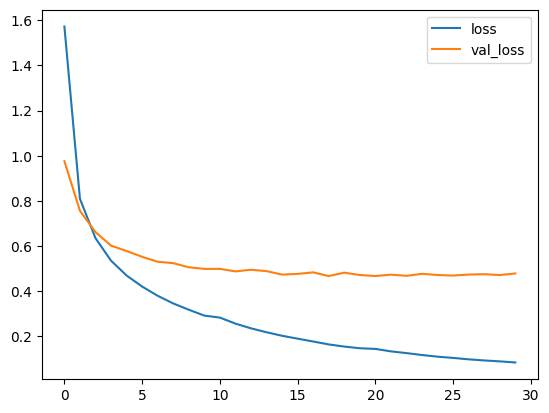

In [22]:
plt.plot(df_hist_new['loss'],label="loss")
plt.plot(df_hist_new['val_loss'],label="val_loss")
plt.legend()
plt.show()

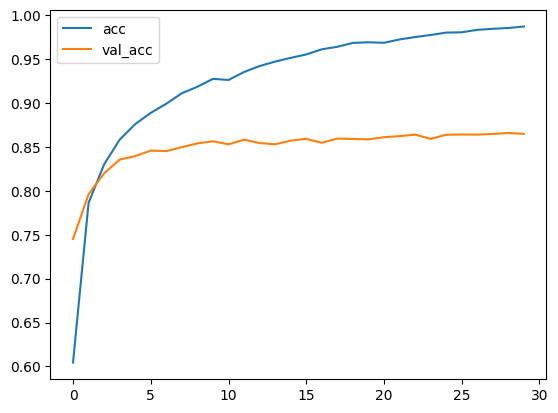

In [23]:
plt.plot(df_hist_new['accuracy'],label="acc")
plt.plot(df_hist_new['val_accuracy'],label="val_acc")
plt.legend()
plt.show()

In [24]:
model.save("ResNet50Tune.keras")

In [25]:
shutil.copy(
    "ResNet50Tune.keras",
    "/content/drive/MyDrive/")

'/content/drive/MyDrive/ResNet50Tune.keras'

In [26]:
Modificar_direc(test, "test")

Se han truncado las últimas 5000 líneas del flujo de salida.
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/23848medium.jpeg --> Data/test/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/22520medium.jpeg --> Data/test/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/19797medium.jpeg --> Data/test/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/21250medium.jpeg --> Data/test/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/20305medium.jpeg --> Data/test/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/23631medium.jpg --> Data/test/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/21238medium.jpg --> Data/test/Fomit

In [27]:
IMG_SIZE = (640, 480)
BATCH_SIZE = 128
test_dataset = tf.keras.utils.image_dataset_from_directory(
    "Data/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_dataset = test_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

Found 6442 files belonging to 54 classes.


In [28]:
y_pred = model.predict(test_dataset)

14/51 ━━━━━━━━━━━━━━━━━━━━ 1:40 3s/step

KeyboardInterrupt: 

In [ ]:
model.evaluate(test_dataset)

In [ ]:
from sklearn.metrics import confusion_matrix

y_true = np.concatenate([y for x, y in test_dataset], axis=0)
y_true_classes = np.argmax(y_true, axis=1)

cm = confusion_matrix(y_true_classes, np.argmax(y_pred, axis=1),
                      normalize= "true")


In [ ]:
import seaborn as sns
plt.figure(figsize=(64,64))
sns.heatmap(cm, annot= True)
plt.show()


In [ ]:
print(classification_report(y_true_classes, np.argmax(y_pred, axis=1)))

In [ ]:
labels = test.label.unique()
name_true = pd.DataFrame({"label":labels[y_true_classes]})
name_pred = pd.DataFrame({"label":labels[np.argmax(y_pred, axis=1)]})

eat_true_df = pd.merge(name_true, info_especies, on='label', how='inner')
eat_pred_df = pd.merge(name_pred, info_especies, on='label', how='inner')

In [ ]:
labs = info_especies.Info.unique()
cm = confusion_matrix(eat_true_df.Info, eat_pred_df.Info, normalize = "true")


sns.heatmap(cm,xticklabels= labs, yticklabels= labs, annot= True)
plt.show()

In [ ]:
n_classes = y_true.shape[1]
y_true_bin = label_binarize(y_true_classes, classes=range(n_classes))

plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr, tpr, thresholds = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Clase {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC One-vs-Rest')
#plt.legend()
plt.grid(True)
plt.show()

In [ ]:
aucs = {}
for i in range(n_classes):
    fpr, tpr, thresholds = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    aucs[i] = roc_auc

plt.figure(figsize=(8,6))
plt.bar(aucs.keys(), aucs.values())
plt.xlabel('Clase')
plt.ylabel('AUC')
plt.title('AUC por Clase')
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve
umbrales = {}

for i in range(n_classes):
    precision, recall, thresholds = precision_recall_curve(
        y_true_bin[:, i],
        y_pred[:, i])
    umbrales[i] = thresholds[np.argmax(precision * recall)]
for i in range(n_classes):
    y_pred_thresholded[:, i] = (y_pred[:, i] >= umbrales[i]).astype(int)

In [ ]:
y_true = np.concatenate([y for x, y in test_dataset], axis=0)
y_true_classes = np.argmax(y_true, axis=1)

cm = confusion_matrix(y_true_classes, np.argmax(y_pred_thresholded, axis=1),
                      normalize= "true")


In [ ]:
plt.figure(figsize=(64,64))
sns.heatmap(cm, annot= True)
plt.show()


In [ ]:
labels = test.label.unique()
name_true = pd.DataFrame({"label":labels[y_true_classes]})
name_pred = pd.DataFrame({"label":labels[np.argmax(y_pred_thresholded, axis=1)]})

eat_true_df = pd.merge(name_true, info_especies, on='label', how='inner')
eat_pred_df = pd.merge(name_pred, info_especies, on='label', how='inner')

In [ ]:
labs = info_especies.Info.unique()
cm = confusion_matrix(eat_true_df.Info, eat_pred_df.Info, normalize = "true")


sns.heatmap(cm,xticklabels= labs, yticklabels= labs, annot= True)
plt.show()

In [ ]:
model.save("ResNet50Tune.keras")
shutil.copy(
    "ResNet50Tune.keras",
    "/content/drive/MyDrive/")

In [ ]:
df_hist_new.to_csv("ResNet50Tune.csv", index=False)
shutil.copy(
    "ResNet50Tune.csv",
    "/content/drive/MyDrive/")


# Fine tuning

Ahora lo que haremos será realizar un fine tuning del modelo

In [ ]:
model_base = tf.keras.models.load_model("ResNet50Tune.keras")
model_base.trainable = True

# congelar todas menos las últimas capas
for layer in model_base.layers[:-30]:
    layer.trainable = False

In [ ]:
model_base.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 640, 480,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 320, 240,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 320, 240,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 320, 240,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 320, 240,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 320, 240,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 320, 240,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 320, 240,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 320, 240,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 320, 240,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 320, 240,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 320, 240,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 321, 241,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 160, 120,  │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 160, 120,  │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 160, 120,  │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 160, 120,  │      2,304 │ block_1_depthwis

 Total params: 2,465,508 (9.41 MB)

 Trainable params: 69,174 (270.21 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 138,350 (540.43 KB)

In [ ]:
model = model_base
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 407s 1s/step - accuracy: 0.8886 - loss: 0.4490 - val_accuracy: 0.7869 - val_loss: 0.7662
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 233s 988ms/step - accuracy: 0.8900 - loss: 0.4428 - val_accuracy: 0.7869 - val_loss: 0.7635
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 228s 969ms/step - accuracy: 0.8901 - loss: 0.4426 - val_accuracy: 0.7869 - val_loss: 0.7624
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 260s 963ms/step - accuracy: 0.8906 - loss: 0.4414 - val_accuracy: 0.7875 - val_loss: 0.7620
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 229s 973ms/step - accuracy: 0.8908 - loss: 0.4405 - val_accuracy: 0.7877 - val_loss: 0.7618
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 232s 982ms/step - accuracy: 0.8914 - loss: 0.4403 - val_accuracy: 0.7872 - val_loss: 0.7617
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 233s 989ms/step - accuracy: 0.8906 - loss: 0.4427 - val_accuracy: 0.7872 - val_loss: 0.7616
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 261s 987ms/step - accuracy: 0.8918 - lo

In [ ]:
model.save("ResNet50Tune.keras")
shutil.copy(
    "ResNet50Tune.keras",
    "/content/drive/MyDrive/")